#Exploratory Data Analysis (EDA)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/iscas89_project')
print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/MyDrive/iscas89_project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

all_data = pd.read_csv('data/processed/all_circuits.csv')
train    = pd.read_csv('data/processed/train.csv')
test     = pd.read_csv('data/processed/test.csv')

FEATURES = ['gate', 'and', 'inv', 'nor', 'nand', 'or', 'dff', 'in', 'out']
FEATURE_LABELS = ['Gates', 'AND', 'Inverters', 'NOR', 'NAND',
                  'OR', 'Flip-flops', 'Inputs', 'Outputs']
os.makedirs('results/figures', exist_ok=True)
print("✓ Data loaded — n =", len(all_data), "circuits")


✓ Data loaded — n = 25 circuits


In [ ]:
def complexity_group(g):
    if g < 200:   return 'Small (<200)'
    elif g < 500: return 'Medium (200–500)'
    else:         return 'Large (>500)'

all_data['complexity'] = all_data['gate'].apply(complexity_group)
print(all_data[['circuit','gate','power','complexity']].to_string(index=False))


circuit  gate   power       complexity
   S208    66 0.00698     Small (<200)
   S298    75 0.00912     Small (<200)
   S349   104 0.01856     Small (<200)
   S386   118 0.01620     Small (<200)
   S400   106 0.01065     Small (<200)
   S420   160 0.00903     Small (<200)
   S444   119 0.01172     Small (<200)
   S713   139 0.03743     Small (<200)
   S820   256 0.02831 Medium (200–500)
   S838   288 0.01292 Medium (200–500)
   S953   311 0.02458 Medium (200–500)
  S1238   428 0.06347 Medium (200–500)
  S1423   490 0.07181 Medium (200–500)
  S1494   558 0.06018     Large (>500)
  S5378  1004 0.23357     Large (>500)
  S9234  2027 0.28004     Large (>500)
 S15850  3448 0.51991     Large (>500)
 S35932 12204 1.22048     Large (>500)
 S38417  8709 1.14518     Large (>500)
 S38584 11448 1.87987     Large (>500)
   S344   101 0.01846     Small (<200)
   S382    99 0.01046     Small (<200)
   S641   107 0.03629     Small (<200)
  S1488   550 0.06018     Large (>500)
 S13207  2573 0.35000    

In [ ]:
import matplotlib.font_manager as fm
fm.fontManager.addfont("times.ttf")
fm.fontManager.addfont("timesbd.ttf")

import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman'],
    'font.weight':       'bold',
    'axes.labelweight':  'bold',
    'axes.titleweight':  'bold',
    'axes.linewidth':    1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'axes.labelsize':    12,
    'axes.titlesize':    11,
    'font.size':         10,
})

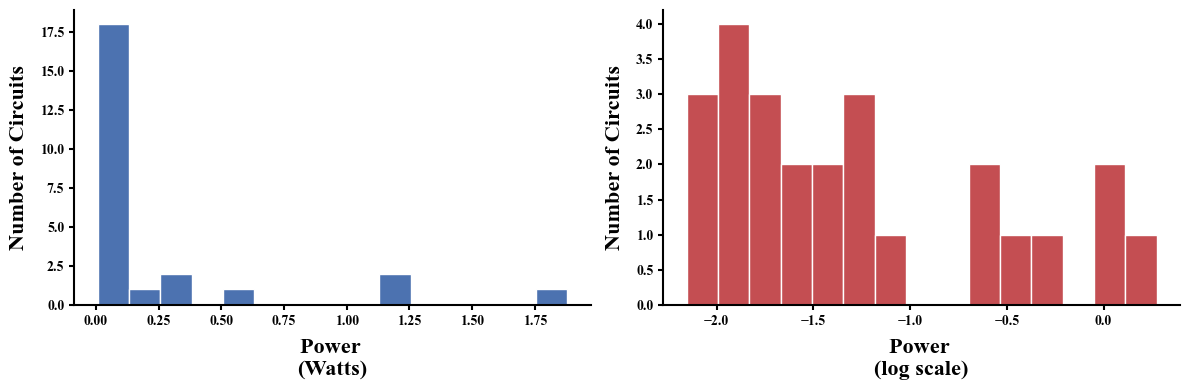

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_data['power'], bins=15, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Power \n(Watts)',
                   fontfamily='serif', fontweight='bold', fontsize=16, labelpad=8)
axes[0].set_ylabel('Number of Circuits',
                   fontfamily='serif', fontweight='bold', fontsize=16, labelpad=8)

axes[0].spines[['top', 'right']].set_visible(False)

axes[1].hist(np.log10(all_data['power']), bins=15, color='#C44E52', edgecolor='white')
axes[1].set_xlabel('Power \n(log scale)',
                   fontfamily='serif', fontweight='bold', fontsize=16, labelpad=8)
axes[1].set_ylabel('Number of Circuits',
                   fontfamily='serif', fontweight='bold', fontsize=16, labelpad=8)

axes[1].spines[['top', 'right']].set_visible(False)

# ── Bold TNR tick labels and spines on both axes ──
for ax in axes:
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('serif')
        tick.set_fontweight('bold')
        tick.set_fontsize(10)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(width=1.5)


plt.tight_layout()
plt.savefig('results/figures/eda_power_dist.png', dpi=600, bbox_inches='tight')
plt.show()


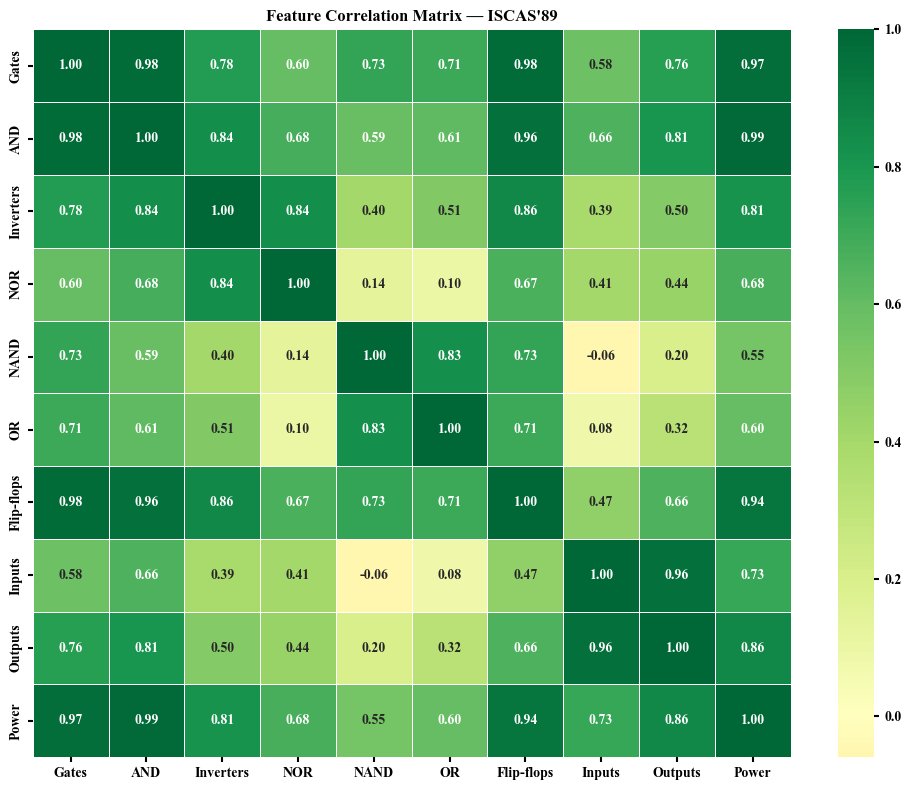


Correlation with power (sorted):
and     0.9897
gate    0.9713
dff     0.9420
out     0.8612
inv     0.8124
in      0.7262
nor     0.6763
or      0.5987
nand    0.5474
Name: power, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = all_data[FEATURES + ['power']].corr()
labels = FEATURE_LABELS + ['Power']
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, linewidths=0.5,
            xticklabels=labels, yticklabels=labels)
ax.set_title("Feature Correlation Matrix — ISCAS\'89", fontsize=12)
plt.tight_layout()
plt.savefig('results/figures/eda_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation with power (sorted):")
print(corr['power'].drop('power').sort_values(ascending=False).round(4))


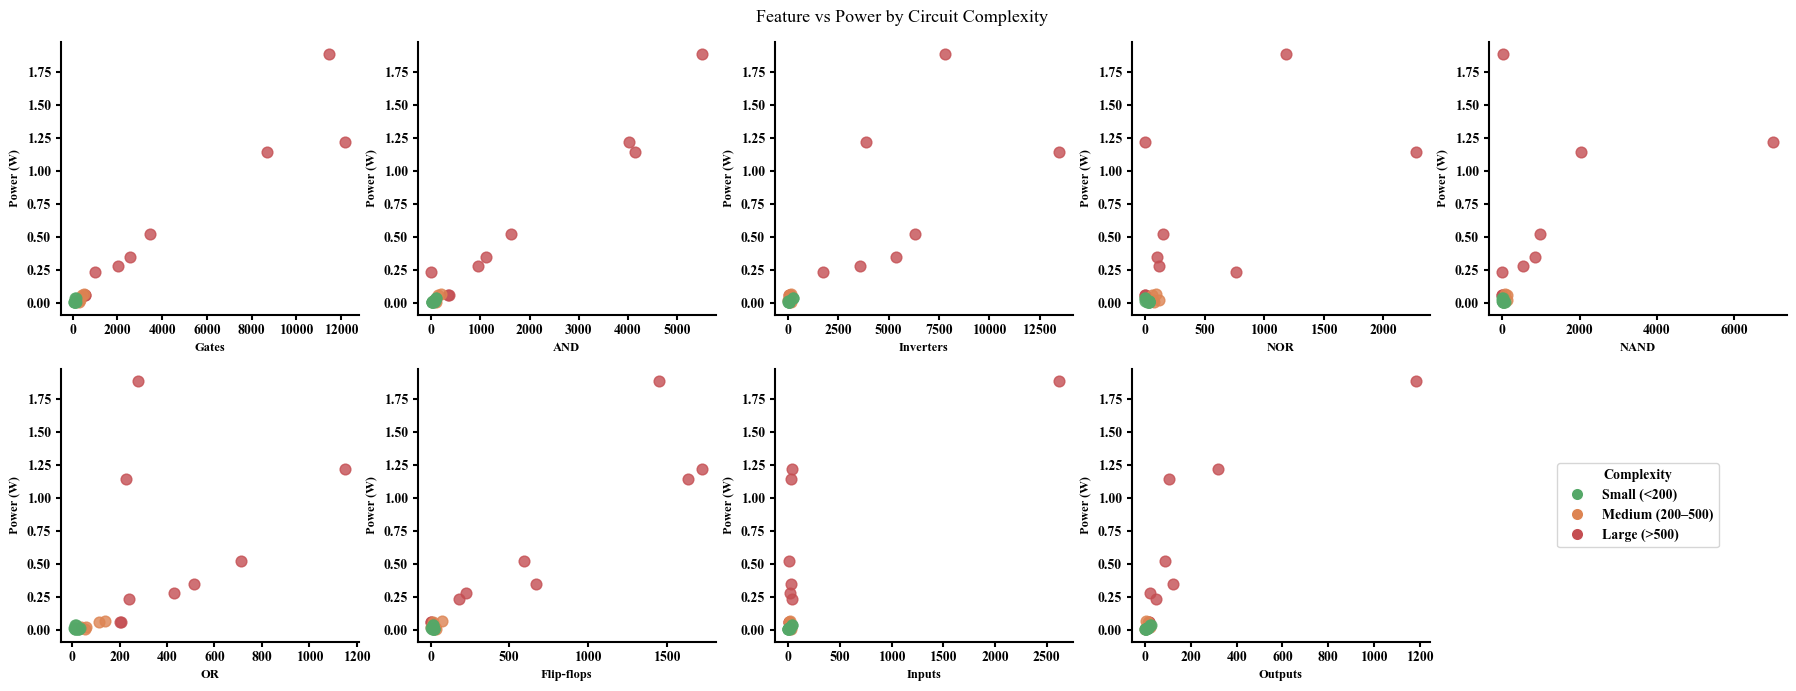

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
colors = {'Small (<200)':'#55A868', 'Medium (200–500)':'#DD8452', 'Large (>500)':'#C44E52'}

for i, feat in enumerate(FEATURES):
    for grp, grp_df in all_data.groupby('complexity'):
        axes[i].scatter(grp_df[feat], grp_df['power'],
                        label=grp, color=colors[grp], s=60, alpha=0.8)
    axes[i].set_xlabel(FEATURE_LABELS[i], fontsize=9)
    axes[i].set_ylabel('Power (W)', fontsize=9)
    axes[i].spines[['top','right']].set_visible(False)

axes[9].axis('off')
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=9, label=l)
           for l, c in colors.items()]
axes[9].legend(handles=handles, title='Complexity', loc='center', fontsize=10)

plt.suptitle('Feature vs Power by Circuit Complexity', fontsize=13)
plt.tight_layout()
plt.savefig('results/figures/eda_feature_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


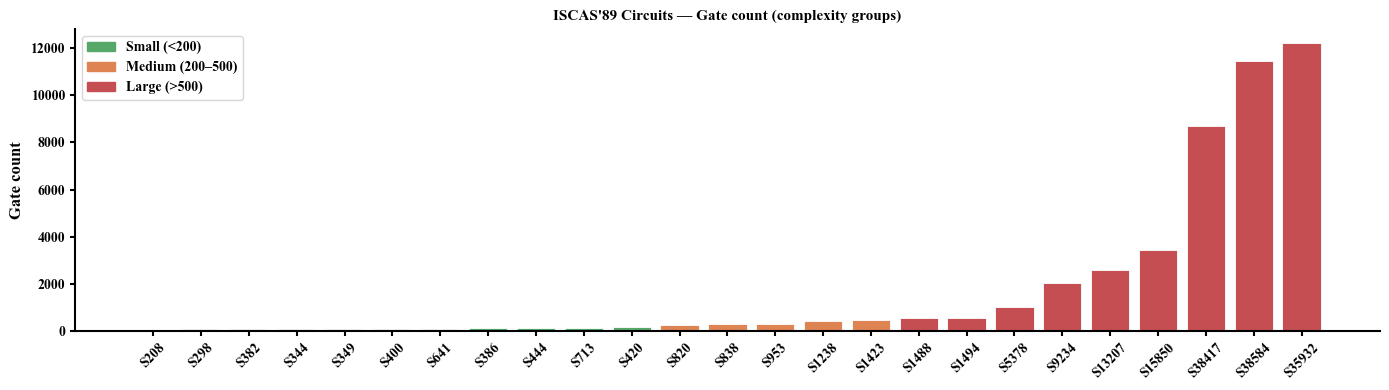

In [ ]:
all_sorted = all_data.sort_values('gate')
color_map  = all_sorted['complexity'].map(colors)

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(all_sorted['circuit'], all_sorted['gate'],
              color=color_map, edgecolor='white', linewidth=0.6)
ax.set_ylabel('Gate count')
ax.set_title('ISCAS\'89 Circuits — Gate count (complexity groups)')
ax.tick_params(axis='x', rotation=45)
handles = [plt.Rectangle((0,0),1,1, color=c, label=l) for l, c in colors.items()]
ax.legend(handles=handles)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/figures/eda_gate_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
